<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/Distribui%C3%A7%C3%A3o_Retornos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalação

In [1]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("HypothesisTests");
Pkg.add("Distributions");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [2]:
using Caramel
using Distributions
using HypothesisTests
using Plots

# Obtenção de Retornos e Visualização

In [16]:
simbolos = ["MCD"]    # McDonalds

logr = get_returns(simbolos, Date(2020,10,01),Date(2025,01,01))

Row,date,MCD
,Date,Float64
1,2020-10-02,0.0139287
2,2020-10-05,0.0151538
3,2020-10-06,-0.00879698
4,2020-10-07,0.010609
5,2020-10-08,-0.00300701
6,2020-10-09,-0.00430528
7,2020-10-12,0.00567721
8,2020-10-13,0.00546911
9,2020-10-14,0.00118696


In [17]:
# Selecionamos todas as linhas do dataframe (logr) e apenas a coluna 2
returns = logr[:, 2]

1068-element Vector{Float64}:
  0.013928747181675997
  0.015153839000016807
 -0.008796979742057546
  0.010608954551805924
 -0.0030070055825793703
 -0.0043052791565210274
  0.005677205200894104
  0.005469108242960757
  0.0011869625537132484
  0.008835169988377394
 -0.0011763681295042592
 -0.014801353848295479
  0.006395391515504914
  ⋮
 -0.00010120362996459923
  0.0037354615838641686
 -0.005490250492656084
 -0.017718831613220902
 -0.0022370005644995155
  0.008406071968465923
 -0.0047605221495089205
  0.009226344438343994
  0.002751437220883721
 -0.00401071757922843
 -0.013785736061889351
  0.0010009681592194762

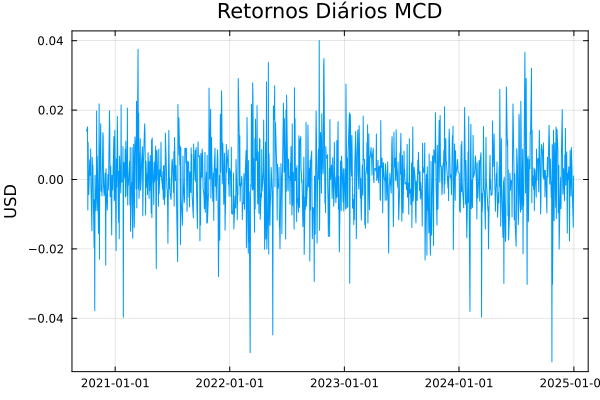

In [18]:
datas = logr[:,:date]  # ou logr[:, 1]
fig2 = plot(datas, returns, title="Retornos Diários $(simbolos[1])",legend = false, ylabel="USD", framestyle = :box)

Iremos calcular de seguida (i) a média (μ) e o (ii) desvio-padrão (σ) dos retornos diários,

In [19]:
mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

μ = 0.0003509217727413198
σ = 0.01064129012196648


## Histograma

Podemos visualizar o histograma dos retorns diário usando o método `histogram()` da bilioteca Plots.jl

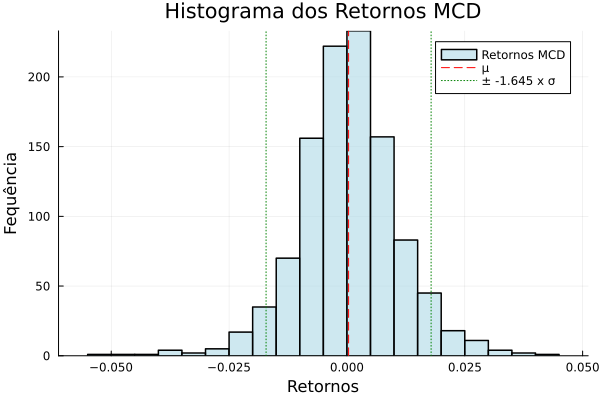

In [20]:
fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolos[1])",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolos[1])",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e z * desvio-padrão

z = - 1.645   # quantil a 5% se distribuição normal(0,1)

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")

display(plot!(fig3))

# Testes de Normalidade

Em que medida uma distribuição normal representa bem a realidade empírica dos retornos observados nos últimos anos?
*   Inspeção Visual
  * $\surd$ Histograma
  * Gráficos Quantil-Quantil (não existe em Plots.jl)
*   Testes Estatísticos de Normalidade
  * Teste de Jarque-Bera
  * Teste de Shapiro-Wilk
  * Teste de Anderson-Darling (não existe em HypothesisTests.jl)





Aqui, usamos a bibioteca de testes estatísticos `HypothesisTests.jl`

Hipótese nula: os retornos têm uma distribuição normal

In [21]:
jb_test = JarqueBeraTest(returns)
println("Teste Jarque-Bera valores-p: ", pvalue(jb_test))

sw_test = ShapiroWilkTest(returns)
println("Teste Shapiro-Wilk valores-p: ", pvalue(sw_test))

Teste Jarque-Bera valores-p: 2.2692678091601578e-46
Teste Shapiro-Wilk valores-p: 9.809989260311008e-12


Estes valores-p são realmente extremamente pequenos! Com o teste de Jarque-Bera e o teste de Shapiro-Wilk temos evidência muito forte para rejeitar a hipótese nula de normalidade para os retornos.
Isto é bastante comum com dados de retornos de ações, que tipicamente apresentam:
*   Caudas pesadas - eventos extremos acontecem com mais frequência do que uma distribuição normal preveria
* Leve assimetria negativa - grandes retornos negativos tendem a ser mais extremos que grandes retornos positivos

Uma vez que rejeitámos a normalidade, ajustar uma distribuição T-Student será um bom próximo passo. Como sabemos, a distribuição T-Student pode acomodar estas caudas pesadas através do seu parâmetro de graus de liberdade ($ν$). Valores mais baixos de ($ν$) indicam caudas mais pesadas.

# Optimizar o Ajustamento da Distribuição dos Retornos
- Normal
- T-Student



## Distribuição Normal

Primeiro ajustamos a distribuição Normal aos retornos observados, o que é muito simples

In [22]:
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)
println("Parâmetros: ", normal_fit)


Parâmetros: Normal{Float64}(μ=0.0003509217727413198, σ=0.01064129012196648)


## Distribuição T-Student

Ajustamos agora a distribuição T-Student aos retornos obervados. Em particular, estaremos interessados em determinar o número óptimo de graus de liberdade ($ν$). A T-Student é parametrizada por: ($ν$) graus de liberdade, (μ) média, e (s) escala. De facto, para a T-Student, a relação entre o desvio-padrão (σ), parâmetro de escala (s) e graus de liberdade ($v$), é dada por,
$$\sigma = s \cdot \sqrt{v\,/\,(v-2)}$$
O Caramel faz o ajustamento à T-Student através do método de máxima verosimilhança.

In [23]:
ν_fit, μ_fit, s_fit = Caramel.fit_mle(TDist, returns)
ν_fit = Int(round(ν_fit))
println("Parâmetros: ν = ", ν_fit, ", μ = ", μ_fit, ", s = ", s_fit)

Parâmetros: ν = 5, μ = 0.000395420291730446, s = 0.00840091204117708


## Validação do Ajustamento Óptimo da T-Student

In [24]:
𝜎_fit = s_fit * sqrt(ν_fit / (ν_fit-2.0))
println("Desvio-padrão da T-Student ajustada = ", 𝜎_fit)

println("Desvio-padrão da amostra = ", σ)

Desvio-padrão da T-Student ajustada = 0.010845530809477397
Desvio-padrão da amostra = 0.01064129012196648


Se o desvio padrão da amostra for muito diferente do da distribuição ajustada, os parâmetros estimados provavelmente estarão incorretos, e deveremos rever o processo de optimização utilizado pelo Caramel: Fminbox(LBFGS()).

# Histograma Empírico com Distribuições Ajustadas Sobrepostas

Vamos criar um gráfico (fig4) que sobrepõe ao histograma com a distrubuição empírica de retornos (fig3) as funções de densidade de probabilidade com ajustamento óptimo que determinámos para as distribuições Normal e T-Student.

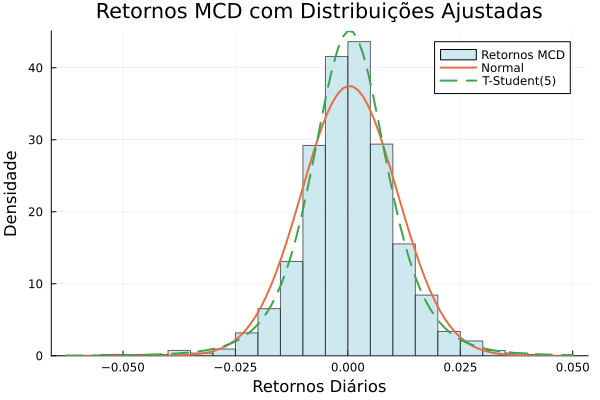

In [25]:
# T-Student
t_fit = LocationScale(μ_fit, s_fit, TDist(ν_fit))  # Usamos LocationScale para obter deslocamento/escala adequados

# Histograma com a distribuição empírica
histogram(returns, bins=30, color=:lightblue, normalize=:pdf, label="Retornos $(simbolos[1])", alpha=0.6)

# Sobrepomos a distribuição Normal ajustada
x_range = range(minimum(returns) - 0.01, maximum(returns) + 0.01, length=100)  # Extendemos o x_range por razões de estética...
plot!(x_range, pdf.(normal_fit, x_range), label="Normal", linewidth=2)

# Sobrepomos a distribuição T-Student óptima ajustada
fig4 = plot!(x_range, pdf.(t_fit, x_range), label="T-Student($ν_fit)", linewidth=2, linestyle=:dash)

title!("Retornos $(simbolos[1]) com Distribuições Ajustadas")
xlabel!("Retornos Diários")
ylabel!("Densidade")